In [1]:
# ============================================================
# 03_email - Email Dataset Model Training
# ============================================================
# Purpose: Train models on raw email text datasets using
#          TF-IDF feature extraction. Separate from the
#          PhiUSIIL URL dataset training in 03_models.ipynb
# ============================================================

In [2]:
import sys, os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, confusion_matrix)
from xgboost import XGBClassifier
import joblib
from src.utils import plot_confusion_matrix

In [3]:
df_email1 = pd.read_csv('../data/processed/email1_clean.csv')
df_email2 = pd.read_csv('../data/processed/email2_clean.csv')

# Rename email2 column to match email1
df_email2 = df_email2.rename(columns={'text': 'text_combined'})

# Combine
df_emails = pd.concat([df_email1, df_email2], ignore_index=True)
df_emails = df_emails.dropna(subset=['text_combined'])
df_emails = df_emails.drop_duplicates()

print(f"Combined email dataset: {df_emails.shape}")
print(f"Label distribution:\n{df_emails['label'].value_counts()}")

Combined email dataset: (99608, 2)
Label distribution:
label
0    50210
1    49398
Name: count, dtype: int64


In [4]:
X_text = df_emails['text_combined']
y      = df_emails['label']

X_temp, X_test_e, y_temp, y_test_e = train_test_split(
    X_text, y,
    test_size=0.15,
    random_state=489,
    stratify=y
)
X_train_e, X_val_e, y_train_e, y_val_e = train_test_split(
    X_temp, y_temp,
    test_size=0.1765,
    random_state=489,
    stratify=y_temp
)

print("Email splits:")
print(f"  Train: {len(X_train_e)}")
print(f"  Val:   {len(X_val_e)}")
print(f"  Test:  {len(X_test_e)}")

Email splits:
  Train: 69722
  Val:   14944
  Test:  14942


In [5]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train_e)
X_val_tfidf   = tfidf.transform(X_val_e)
X_test_tfidf  = tfidf.transform(X_test_e)

print(f"TF-IDF matrix shape: {X_train_tfidf.shape}")

TF-IDF matrix shape: (69722, 5000)


Training RandomForest_Email...


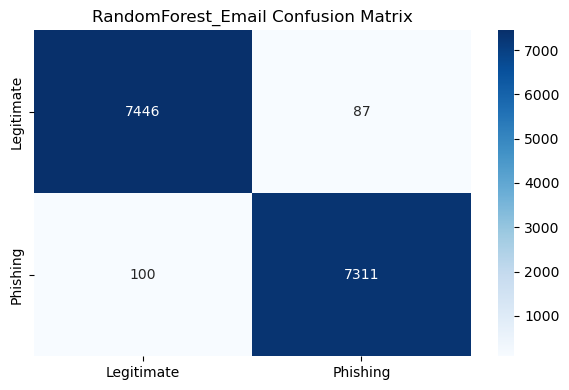

  Accuracy:  0.9875
  Precision: 0.9882
  Recall:    0.9865
  F1:        0.9874
  Inference: 0.0204ms

Training XGBoost_Email...


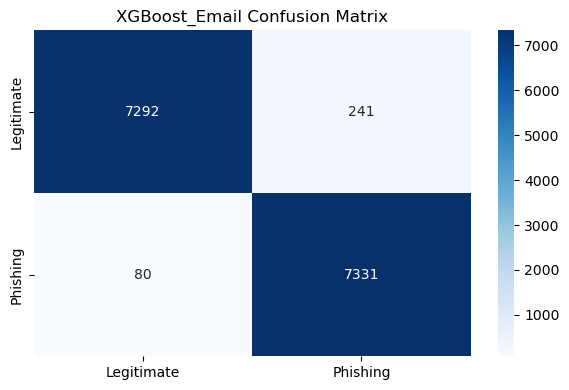

  Accuracy:  0.9785
  Precision: 0.9682
  Recall:    0.9892
  F1:        0.9786
  Inference: 0.0006ms

Training DecisionTree_Email...


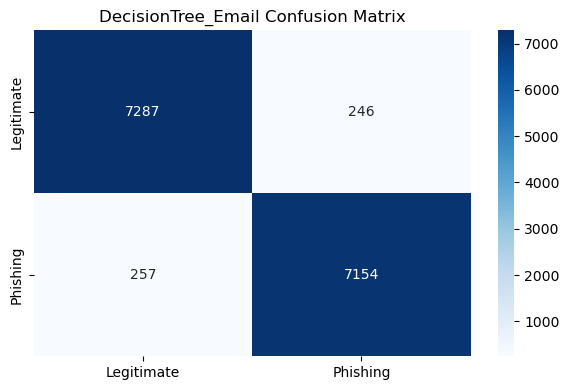

  Accuracy:  0.9663
  Precision: 0.9668
  Recall:    0.9653
  F1:        0.9660
  Inference: 0.0004ms



In [6]:
email_models = {
    'RandomForest_Email': RandomForestClassifier(
                              n_estimators=100, random_state=489),
    'XGBoost_Email':      XGBClassifier(
                              random_state=489, eval_metric='logloss'),
    'DecisionTree_Email': DecisionTreeClassifier(random_state=489)
}

email_results = []
for name, model in email_models.items():
    print(f"Training {name}...")
    model.fit(X_train_tfidf, y_train_e)

    start = time.time()
    y_pred = model.predict(X_val_tfidf)
    inference_ms = (time.time() - start) / len(y_val_e) * 1000

    metrics = {
        'model':        name,
        'accuracy':     accuracy_score(y_val_e, y_pred),
        'precision':    precision_score(y_val_e, y_pred,
                                        zero_division=0),
        'recall':       recall_score(y_val_e, y_pred,
                                     zero_division=0),
        'f1':           f1_score(y_val_e, y_pred,
                                 zero_division=0),
        'auc':          roc_auc_score(y_val_e, y_pred),
        'inference_ms': round(inference_ms, 4)
    }
    email_results.append(metrics)

    cm = confusion_matrix(y_val_e, y_pred)
    plot_confusion_matrix(cm, name)

    print(f"  Accuracy:  {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  F1:        {metrics['f1']:.4f}")
    print(f"  Inference: {metrics['inference_ms']:.4f}ms\n")

In [7]:
email_results_df = pd.DataFrame(email_results)
email_results_df.to_csv('../results/email_metrics.csv', index=False)

print("Email results saved to results/email_metrics.csv")
print(email_results_df[['model','accuracy','precision',
                         'recall','f1','auc','inference_ms']])

Email results saved to results/email_metrics.csv
                model  accuracy  precision    recall        f1       auc  \
0  RandomForest_Email  0.987487   0.988240  0.986507  0.987373  0.987479   
1       XGBoost_Email  0.978520   0.968172  0.989205  0.978576  0.978606   
2  DecisionTree_Email  0.966341   0.966757  0.965322  0.966039  0.966333   

   inference_ms  
0        0.0204  
1        0.0006  
2        0.0004  


In [8]:
best_email_model_name = email_results_df.loc[
    email_results_df['accuracy'].idxmax(), 'model'
]
print(f"Best email model: {best_email_model_name}")

best_email_model = email_models[best_email_model_name]
y_test_pred = best_email_model.predict(X_test_tfidf)

print("\n=== FINAL EMAIL TEST SET RESULTS ===")
print(f"Accuracy:  {accuracy_score(y_test_e, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test_e, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test_e, y_test_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test_e, y_test_pred):.4f}")

Best email model: RandomForest_Email

=== FINAL EMAIL TEST SET RESULTS ===
Accuracy:  0.9874
Precision: 0.9892
Recall:    0.9853
F1-Score:  0.9872
